[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alanturin-g/Computational_Neuroscience_UNITO/blob/main/Perotti_6_fMRI_ML_complete.ipynb)

In [ ]:
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

# fMRI Machine Learning: From 4D Tensors to Classification

**Goal**: Learn to work with 4D fMRI data and build a machine learning classifier to distinguish between brain activity when viewing faces vs. houses.

**Dataset**: Haxby face/house fMRI dataset
- 216 brain scans (time points)
- 64 × 64 × 40 voxels per scan
- 2 categories: faces and houses
- 12 experimental runs

---

**Key Concepts**:
- Understanding 4D neuroimaging data structure
- Visualizing brain slices in different planes
- Proper train/test splitting for fMRI (by runs, not random!)
- Dimensionality reduction with t-SNE
- Classification and evaluation metrics

## Step 1: Install and Import Libraries

In [1]:
# Install nilearn if needed (uncomment if running in Colab)
#!pip install nilearn

In [2]:
# Basic Python libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Neuroscience libraries
from nilearn.image import index_img
from nilearn import datasets
import nibabel as nib

# Machine learning libraries
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Settings
import warnings
warnings.filterwarnings('ignore')
np.set_printoptions(legacy='1.13')  # Fix numpy printing

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Step 2: Load the Haxby Dataset

The Haxby dataset is a classic fMRI study investigating how the brain processes faces versus objects.

**What we're loading:**
- `func`: Functional MRI data (4D: time × x × y × z)
- `session_target`: Labels for each time point (face, house, etc.)
- `mask`: Brain mask defining which voxels are inside the brain

In [3]:
# Download the Haxby dataset (will cache locally after first download)
haxby_dataset = datasets.fetch_haxby()

print("Dataset files:")
for key in haxby_dataset.keys():
    print(f"  {key}: {type(haxby_dataset[key])}")

[fetch_haxby] Dataset found in /Users/alan/nilearn_data/haxby2001

Dataset files:
  anat: <class 'list'>
  func: <class 'list'>
  session_target: <class 'list'>
  mask_vt: <class 'list'>
  mask_face: <class 'list'>
  mask_house: <class 'list'>
  mask_face_little: <class 'list'>
  mask_house_little: <class 'list'>
  mask: <class 'str'>
  description: <class 'str'>


## Step 3: Explore the Behavioral Data

Before looking at brain images, let's understand the experimental design.

In [4]:
# Load the behavioral data (what stimuli were shown when)
behavioral_data = pd.read_csv(haxby_dataset.session_target[0], sep=" ")

print(f"Behavioral data shape: {behavioral_data.shape}")
print(f"\nColumns: {list(behavioral_data.columns)}")
print(f"\nFirst few rows:")
behavioral_data.head()

Behavioral data shape: (1452, 2)

Columns: ['labels', 'chunks']

First few rows:


,labels,chunks
0,rest,0
1,rest,0
2,rest,0
3,rest,0
4,rest,0


In [5]:
# What categories were shown to the subject?
print("Stimulus categories:")
print(behavioral_data['labels'].unique())

print(f"\nCategory counts:")
print(behavioral_data['labels'].value_counts())

Stimulus categories:
['rest' 'scissors' 'face' 'cat' 'shoe' 'house' 'scrambledpix' 'bottle'
 'chair']

Category counts:
labels
rest            588
scissors        108
face            108
cat             108
shoe            108
house           108
scrambledpix    108
bottle          108
chair           108
Name: count, dtype: int64


In [6]:
# How many experimental runs?
print("Experimental runs (chunks):")
print(behavioral_data['chunks'].unique())

print(f"\nSamples per run:")
print(behavioral_data['chunks'].value_counts().sort_index())

Experimental runs (chunks):
[ 0  1  2  3  4  5  6  7  8  9 10 11]

Samples per run:
chunks
0     121
1     121
2     121
3     121
4     121
5     121
6     121
7     121
8     121
9     121
10    121
11    121
Name: count, dtype: int64


## Step 4: Select Face vs. House Trials

For this analysis, we'll focus on a binary classification: **faces vs. houses**.

This is a simpler problem than multi-class classification and allows us to focus on the methodology.

In [7]:
# Create a binary mask: True for face/house trials, False for others
labels = behavioral_data["labels"]
labels_mask = ((labels == "face") | (labels == "house"))

print("Binary mask statistics:")
unique, counts = np.unique(labels_mask, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  {val}: {count} samples")

print(f"\n→ We'll use {labels_mask.sum()} samples (face or house)")
print(f"→ We'll ignore {(~labels_mask).sum()} samples (other categories)")

Binary mask statistics:
  False: 1236 samples
  True: 216 samples

→ We'll use 216 samples (face or house)
→ We'll ignore 1236 samples (other categories)


In [8]:
# Extract the labels we care about (face or house)
y = labels[labels_mask].to_numpy()

print("Target variable (y) - class distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} samples ({count/len(y)*100:.1f}%)")

print(f"\n✓ Classes are perfectly balanced!")

Target variable (y) - class distribution:
  face: 108 samples (50.0%)
  house: 108 samples (50.0%)

✓ Classes are perfectly balanced!


In [9]:
# Also extract the run information (we'll need this for proper train/test split)
run = behavioral_data["chunks"][labels_mask].to_numpy()

print("Run distribution for face/house trials:")
unique_runs, counts_per_run = np.unique(run, return_counts=True)
for run_num, count in zip(unique_runs, counts_per_run):
    print(f"  Run {run_num}: {count} samples")

print(f"\n→ Each run has exactly {counts_per_run[0]} face/house trials")

Run distribution for face/house trials:
  Run 0: 18 samples
  Run 1: 18 samples
  Run 2: 18 samples
  Run 3: 18 samples
  Run 4: 18 samples
  Run 5: 18 samples
  Run 6: 18 samples
  Run 7: 18 samples
  Run 8: 18 samples
  Run 9: 18 samples
  Run 10: 18 samples
  Run 11: 18 samples

→ Each run has exactly 18 face/house trials


## Step 5: Load the fMRI Data and Understand the Structure

Now we'll load the actual brain images. This is where things get interesting!

**What we're loading:**
- A 4D tensor with dimensions: **(time, x, y, z)**
- Time: 216 brain scans (one per trial)
- X, Y, Z: 3D spatial coordinates of brain voxels

### 🧠 Understanding the Data Structure

**The 216 Datapoints - What Do They Represent?**

The number 216 comes from the experimental design:
- **12 runs** (experimental blocks)
- **18 face/house trials per run** (9 faces + 9 houses)
- **12 × 18 = 216 total trials**

Each datapoint is a **3D brain snapshot** taken during one trial when the subject was viewing either a face or house image.

**What Are "Runs"?**

A "run" is a continuous scanning session (~10 minutes):
- Subject stays in scanner
- Views multiple stimuli in sequence
- Each run contains ALL stimulus categories (faces, houses, shoes, etc.)
- Short breaks between runs (subject can move slightly, readjust)

Think of runs as "chapters" in the experiment - each chapter tells a complete story, but the story is told 12 times.

**Why Do Runs Matter for Machine Learning?**

Runs create **temporal dependencies**:
- Brain state evolves continuously within a run
- Slow drifts in signal (scanner warming up, subject getting tired)
- Autocorrelation: observations close in time are more similar
- Head position slightly different between runs

⚠️ **CRITICAL**: We must split train/test by RUNS, not randomly!
- Random split = observations from same run in both train AND test
- This creates **data leakage** (similar to EEG time series problem!)
- Test data would be "too close" to training data
- Inflated performance estimates

**Time in fMRI vs. Time in EEG**

| Property | fMRI (this dataset) | EEG (Perotti_5a) |
|----------|---------------------|------------------|
| Sampling rate | ~0.5-2 Hz (slow) | 128 Hz (fast) |
| Adjacent samples | Different stimuli (usually) | Same stimulus (highly correlated) |
| Independence | Moderate (block design) | Low (continuous signal) |
| Shuffle danger | ⚠️ Moderate (run-level leakage) | 🚨 CRITICAL (instant leakage) |

**Can We Treat Samples as Independent?**

Within runs? **NO** - temporally correlated  
Across runs? **MOSTLY** - different scanning sessions  
→ Solution: **Split by runs** (some runs for train, others for test)

In [10]:
# Load only the face/house trials using our mask
fmri_img = index_img(haxby_dataset.func[0], labels_mask)

# Convert to numpy array and transpose to (time, x, y, z)
fmri_tensor = fmri_img.get_fdata().T

print(f"fMRI tensor shape: {fmri_tensor.shape}")
print(f"\nDimension breakdown:")
print(f"  Dimension 0 (time):  {fmri_tensor.shape[0]} brain scans")
print(f"  Dimension 1 (X):     {fmri_tensor.shape[1]} voxels (left ↔ right)")
print(f"  Dimension 2 (Y):     {fmri_tensor.shape[2]} voxels (back ↔ front)")
print(f"  Dimension 3 (Z):     {fmri_tensor.shape[3]} voxels (bottom ↔ top)")
print(f"\nTotal voxels per scan: {fmri_tensor.shape[1] * fmri_tensor.shape[2] * fmri_tensor.shape[3]:,}")

fMRI tensor shape: (216, 64, 64, 40)

Dimension breakdown:
  Dimension 0 (time):  216 brain scans
  Dimension 1 (X):     64 voxels (left ↔ right)
  Dimension 2 (Y):     64 voxels (back ↔ front)
  Dimension 3 (Z):     40 voxels (bottom ↔ top)

Total voxels per scan: 163,840


## Step 6: Visualizing Brain Slices

We can visualize the 3D brain by taking 2D "slices" through different planes:

1. **Sagittal** (slice through X): View from the side (left/right)
2. **Coronal** (slice through Y): View from the front/back
3. **Axial** (slice through Z): View from the top/bottom

This is similar to how MRI scans are viewed in medical imaging.

In [11]:
def brain_slice_plotter(datablock, indexes):
    """
    Visualize 3D brain slices from a 4D fMRI tensor.
    
    Parameters
    ----------
    datablock : ndarray, shape (time, x, y, z)
        4D fMRI data tensor
    indexes : list of int
        [time_idx, x_idx, y_idx, z_idx] - indices to slice at
        If empty list, uses random indices
        
    Returns
    -------
    None (displays plots)
    """
    # If no indices provided, use random ones
    if indexes == []:
        indexes = [np.random.randint(datablock.shape[i]) for i in range(4)]
    
    it, ix, iy, iz = indexes
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Sagittal slice (looking from the side)
    im1 = axes[0].imshow(datablock[it, ix, :, :].T, cmap='Blues', origin='lower')
    axes[0].set_title(f'Sagittal Slice (X={ix})\nTime point: {it}', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Y (back → front)', fontsize=10)
    axes[0].set_ylabel('Z (bottom → top)', fontsize=10)
    plt.colorbar(im1, ax=axes[0], label='BOLD signal', fraction=0.046)
    
    # Coronal slice (looking from front/back)
    im2 = axes[1].imshow(datablock[it, :, iy, :].T, cmap='Blues', origin='lower')
    axes[1].set_title(f'Coronal Slice (Y={iy})\nTime point: {it}', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('X (left → right)', fontsize=10)
    axes[1].set_ylabel('Z (bottom → top)', fontsize=10)
    plt.colorbar(im2, ax=axes[1], label='BOLD signal', fraction=0.046)
    
    # Axial slice (looking from top/bottom)
    im3 = axes[2].imshow(datablock[it, :, :, iz].T, cmap='Blues', origin='lower')
    axes[2].set_title(f'Axial Slice (Z={iz})\nTime point: {it}', fontweight='bold', fontsize=12)
    axes[2].set_xlabel('X (left → right)', fontsize=10)
    axes[2].set_ylabel('Y (back → front)', fontsize=10)
    plt.colorbar(im3, ax=axes[2], label='BOLD signal', fraction=0.046)
    
    plt.tight_layout()
    plt.show()

print("✓ Brain slice plotter function defined")

✓ Brain slice plotter function defined


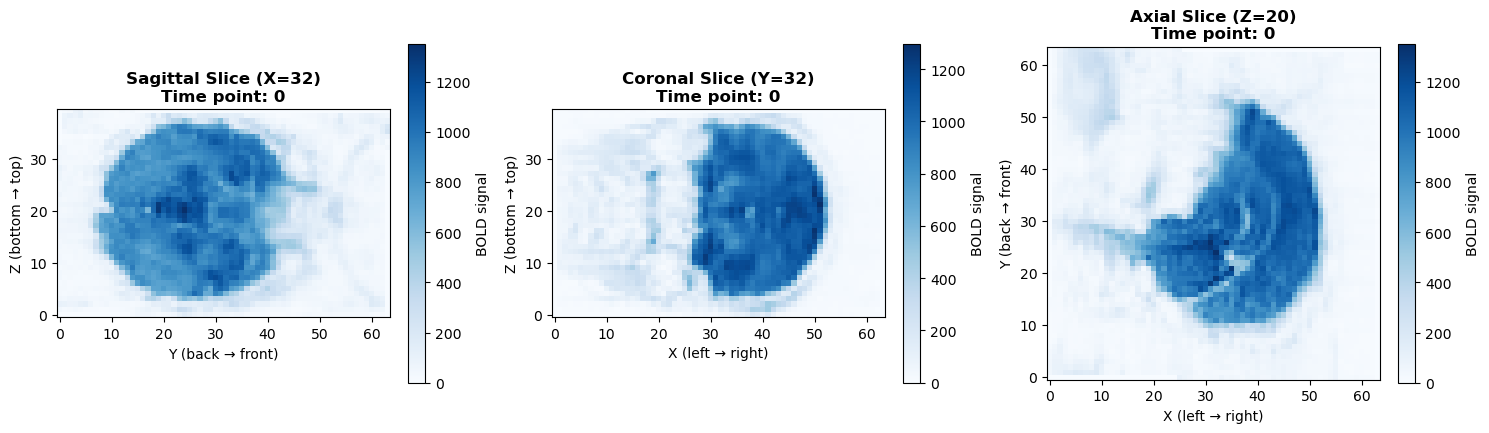

In [12]:
# Visualize the first time point (t=0)
# Using slices near the center of the brain
brain_slice_plotter(fmri_tensor, [0, 32, 32, 20])

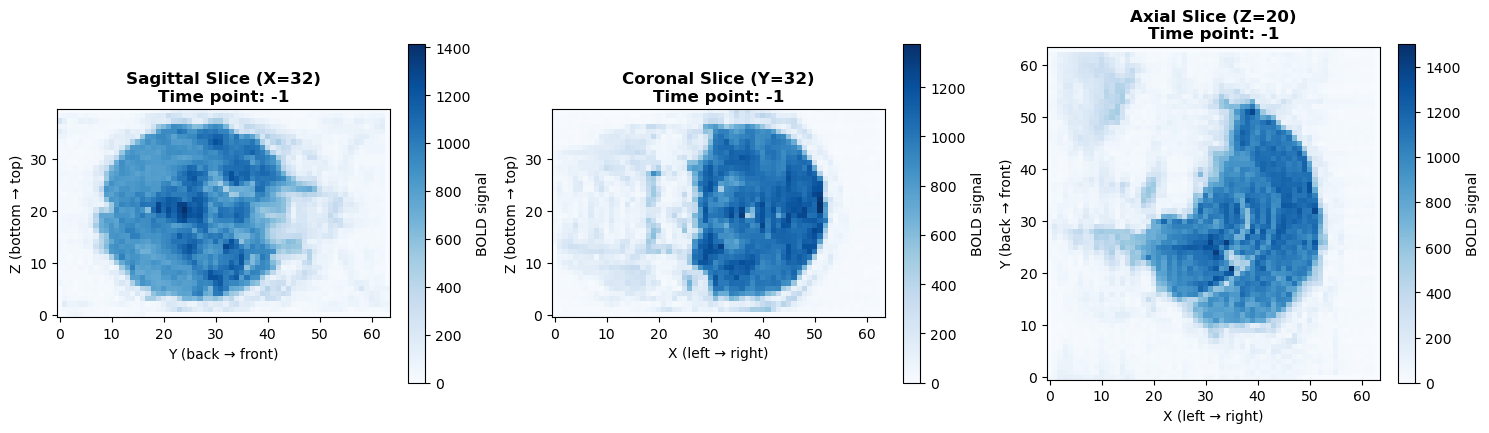

In [13]:
# Visualize the last time point (t=-1)
brain_slice_plotter(fmri_tensor, [-1, 32, 32, 20])

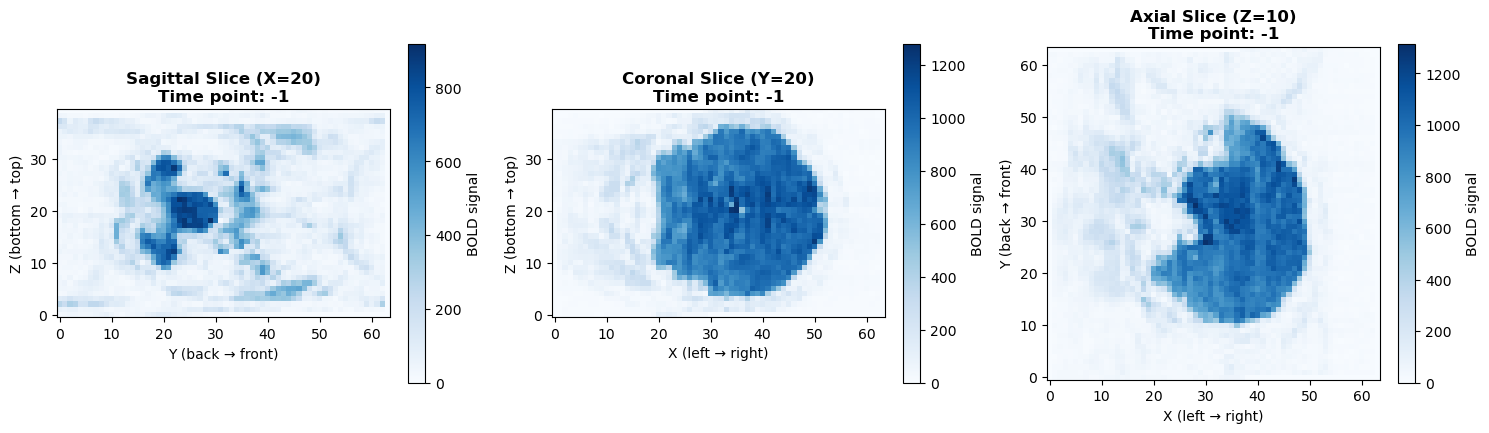

In [14]:
# Visualize the last time point (t=-1)
brain_slice_plotter(fmri_tensor, [-1, 20, 20, 10])

## Step 7: Flatten the Data for Machine Learning

Most ML algorithms expect 2D input: (samples, features)

We need to convert:
- From: **(216, 64, 64, 40)** → 216 samples with 3D structure
- To: **(216, 163840)** → 216 samples with flat features

In [15]:
# Flatten the 4D tensor to 2D
# -1 means "compute this dimension automatically"
flat_fmri = fmri_tensor.reshape((216, -1))

print(f"Original shape: {fmri_tensor.shape}")
print(f"Flattened shape: {flat_fmri.shape}")
print(f"\nInterpretation:")
print(f"  {flat_fmri.shape[0]} samples (brain scans)")
print(f"  {flat_fmri.shape[1]:,} features (voxels)")
print(f"\n✓ Ready for machine learning!")

Original shape: (216, 64, 64, 40)
Flattened shape: (216, 163840)

Interpretation:
  216 samples (brain scans)
  163,840 features (voxels)

✓ Ready for machine learning!


## Step 8: Dimensionality Reduction with t-SNE

Before training, let's visualize the data in 2D using t-SNE.

**t-SNE** (t-Distributed Stochastic Neighbor Embedding):
- Reduces high-dimensional data to 2D/3D for visualization
- Preserves local structure (similar samples stay close together)
- Helps us understand if the data is separable

In [16]:
# Run t-SNE: 163,840 features → 2 features
print("Running t-SNE... (this may take a minute)")
tsne = TSNE(n_components=2, verbose=0, perplexity=10, max_iter=300, random_state=42)
tsned = tsne.fit_transform(np.nan_to_num(flat_fmri, nan=0))

print(f"\nt-SNE output shape: {tsned.shape}")
print(f"  {tsned.shape[0]} samples")
print(f"  {tsned.shape[1]} t-SNE components")
print("\n✓ t-SNE completed!")

Running t-SNE... (this may take a minute)

t-SNE output shape: (216, 2)
  216 samples
  2 t-SNE components

✓ t-SNE completed!


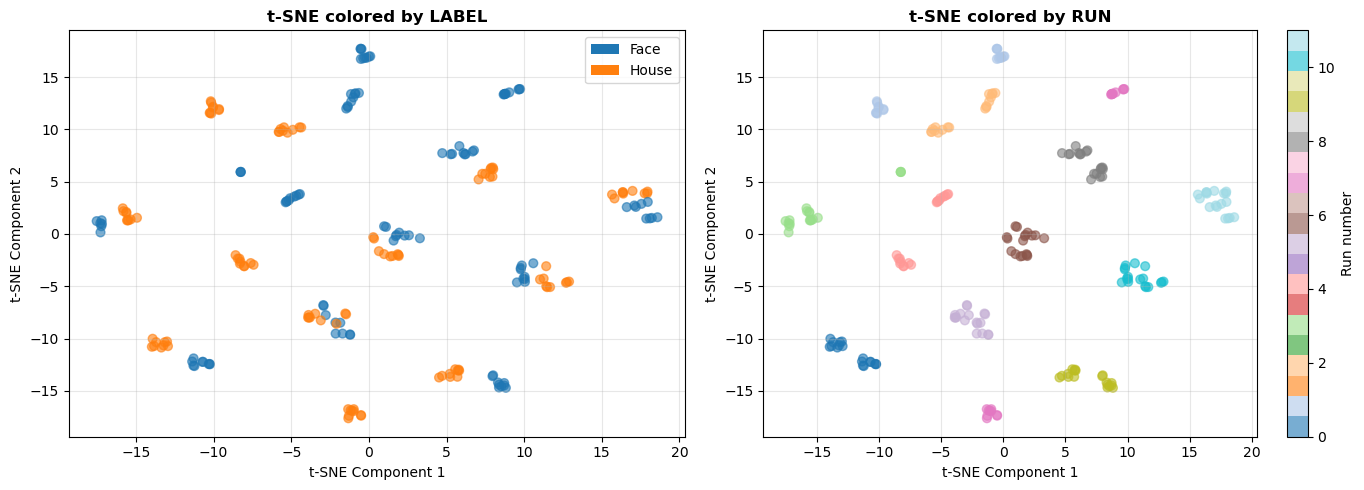


💡 Key Observations:
   LEFT: Face and house trials show some separation (good for classification!)
   RIGHT: Different runs cluster together (temporal structure!)

⚠️  CRITICAL: We must split by RUNS, not randomly!
   Random splitting would leak information between train/test.


In [17]:
# Visualize t-SNE results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Colored by label (face vs house)
colors_label = ['#1f77b4' if label == 'face' else '#ff7f0e' for label in y]
axes[0].scatter(tsned[:, 0], tsned[:, 1], c=colors_label, alpha=0.6, s=40)
axes[0].set_title('t-SNE colored by LABEL', fontweight='bold', fontsize=12)
axes[0].set_xlabel('t-SNE Component 1', fontsize=10)
axes[0].set_ylabel('t-SNE Component 2', fontsize=10)
axes[0].grid(alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Face'),
                  Patch(facecolor='#ff7f0e', label='House')]
axes[0].legend(handles=legend_elements, loc='best')

# Plot 2: Colored by run
scatter = axes[1].scatter(tsned[:, 0], tsned[:, 1], c=run, cmap='tab20', alpha=0.6, s=40)
axes[1].set_title('t-SNE colored by RUN', fontweight='bold', fontsize=12)
axes[1].set_xlabel('t-SNE Component 1', fontsize=10)
axes[1].set_ylabel('t-SNE Component 2', fontsize=10)
axes[1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Run number')

plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("   LEFT: Face and house trials show some separation (good for classification!)")
print("   RIGHT: Different runs cluster together (temporal structure!)")
print("\n⚠️  CRITICAL: We must split by RUNS, not randomly!")
print("   Random splitting would leak information between train/test.")

## Step 9: Train/Test Split by Runs

**Why split by runs?**
- fMRI data has temporal dependencies within runs
- Random splitting would leak information (data from same run in both train/test)
- We want to test on completely independent data

**Strategy**: Hold out 3 runs (25%) for testing

**Why This Matters:**

Imagine we randomly shuffle all 216 trials:
- Run 3 trial #5 goes to training
- Run 3 trial #6 goes to testing
- These were recorded 10 seconds apart in the same scanning session!
- They share: similar head position, scanner state, brain baseline
- The model can "cheat" by memorizing these confounds

**By splitting by runs:**
- Training runs: 0, 1, 3, 4, 5, 7, 8, 9, 11 (completely separate sessions)
- Test runs: 2, 6, 10 (the model has NEVER seen any data from these sessions)
- Forces the model to learn true face/house patterns, not session-specific artifacts

In [18]:
# Strategic decision: runs 2, 6, 10 go to test set
# Evenly spread across the experiment timeline:
#   Run 2:  17% through experiment (early)
#   Run 6:  50% through experiment (middle)
#   Run 10: 83% through experiment (late)
# This ensures test data represents the full temporal range
test_runs = [2, 6, 10]

# Create train/test indices based on runs
train_index = np.where(~np.isin(run, test_runs))[0]
test_index = np.where(np.isin(run, test_runs))[0]

# Split the data
xtrn, xtst = flat_fmri[train_index], flat_fmri[test_index]
ytrn, ytst = y[train_index], y[test_index]

print(f"Train set: {xtrn.shape[0]} samples ({xtrn.shape[0]/len(flat_fmri)*100:.1f}%)")
print(f"Test set:  {xtst.shape[0]} samples ({xtst.shape[0]/len(flat_fmri)*100:.1f}%)")
print(f"\nFeatures: {xtrn.shape[1]:,} voxels")

# Check class distribution
print(f"\nTrain class distribution:")
unique_train, counts_train = np.unique(ytrn, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"  {label}: {count} ({count/len(ytrn)*100:.1f}%)")

print(f"\nTest class distribution:")
unique_test, counts_test = np.unique(ytst, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"  {label}: {count} ({count/len(ytst)*100:.1f}%)")

Train set: 162 samples (75.0%)
Test set:  54 samples (25.0%)

Features: 163,840 voxels

Train class distribution:
  face: 81 (50.0%)
  house: 81 (50.0%)

Test class distribution:
  face: 27 (50.0%)
  house: 27 (50.0%)


## Step 10: Train a Random Forest Classifier

**Random Forest**:
- Ensemble of decision trees
- Robust and interpretable
- Good baseline for fMRI classification
- No feature scaling needed

In [19]:
# Train the model
print("Training Random Forest classifier...")
brain_ml_model = RFC(n_estimators=100, max_depth=10, random_state=42)
brain_ml_model.fit(xtrn, ytrn)

# Make predictions
train_pred = brain_ml_model.predict(xtrn)
test_pred = brain_ml_model.predict(xtst)

# Evaluate
train_acc = accuracy_score(ytrn, train_pred)
test_acc = accuracy_score(ytst, test_pred)

print(f"\n✓ Training complete!")
print(f"\nResults:")
print(f"  Training accuracy: {train_acc:.3f} ({train_acc*100:.1f}%)")
print(f"  Test accuracy:     {test_acc:.3f} ({test_acc*100:.1f}%)")
print(f"\nNote: Test accuracy is what matters for generalization!")

Training Random Forest classifier...

✓ Training complete!

Results:
  Training accuracy: 1.000 (100.0%)
  Test accuracy:     0.685 (68.5%)

Note: Test accuracy is what matters for generalization!


## Step 11: Confusion Matrix

The confusion matrix shows:
- **Diagonal**: Correct predictions
- **Off-diagonal**: Errors (confusions between classes)

In [20]:
# Check which class is 0 and which is 1
print("Model classes:")
print(f"  Class 0: {brain_ml_model.classes_[0]}")
print(f"  Class 1: {brain_ml_model.classes_[1]}")

Model classes:
  Class 0: face
  Class 1: house


In [21]:
# Compute confusion matrix
cm = confusion_matrix(ytst, test_pred)

print("\nConfusion Matrix:")
print(cm)
print("\n        Predicted")
print("        Face  House")
print(f"Actual Face   {cm[0,0]:3d}   {cm[0,1]:3d}")
print(f"       House  {cm[1,0]:3d}   {cm[1,1]:3d}")

# Calculate error types
correct = cm[0,0] + cm[1,1]
total = cm.sum()
false_face = cm[1,0]  # Said face, but was house
false_house = cm[0,1]  # Said house, but was face

print(f"\nBreakdown:")
print(f"  Correct predictions: {correct}/{total} ({correct/total*100:.1f}%)")
print(f"  False faces: {false_face} (predicted face, actually house)")
print(f"  False houses: {false_house} (predicted house, actually face)")


Confusion Matrix:
[[20  7]
 [10 17]]

        Predicted
        Face  House
Actual Face    20     7
       House   10    17

Breakdown:
  Correct predictions: 37/54 (68.5%)
  False faces: 10 (predicted face, actually house)
  False houses: 7 (predicted house, actually face)


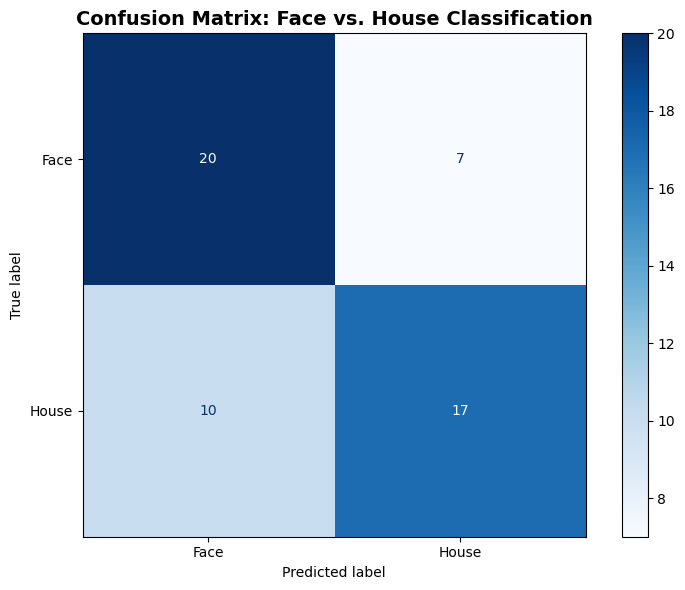

In [22]:
# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Face', 'House'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.set_title('Confusion Matrix: Face vs. House Classification', 
            fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## Step 12: ROC Curve and AUC

**ROC Curve** (Receiver Operating Characteristic):
- Shows classifier performance across all decision thresholds
- X-axis: False Positive Rate (false alarms)
- Y-axis: True Positive Rate (correct detections)

**AUC** (Area Under Curve):
- Single number summarizing ROC curve
- 1.0 = perfect, 0.5 = random, 0.0 = perfectly wrong

In [23]:
# Get probability predictions (not just 0/1, but confidence)
test_proba = brain_ml_model.predict_proba(xtst)[:, 1]

# Convert labels to binary (0/1)
ytst_bin = [list(brain_ml_model.classes_).index(elem) for elem in ytst]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(ytst_bin, test_proba)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC Score: {roc_auc:.3f}")
print(f"\nInterpretation:")
if roc_auc > 0.9:
    print("  Excellent classification!")
elif roc_auc > 0.8:
    print("  Good classification")
elif roc_auc > 0.7:
    print("  Fair classification")
elif roc_auc > 0.6:
    print("  Poor classification")
else:
    print("  Barely better than random")

ROC AUC Score: 0.773

Interpretation:
  Fair classification


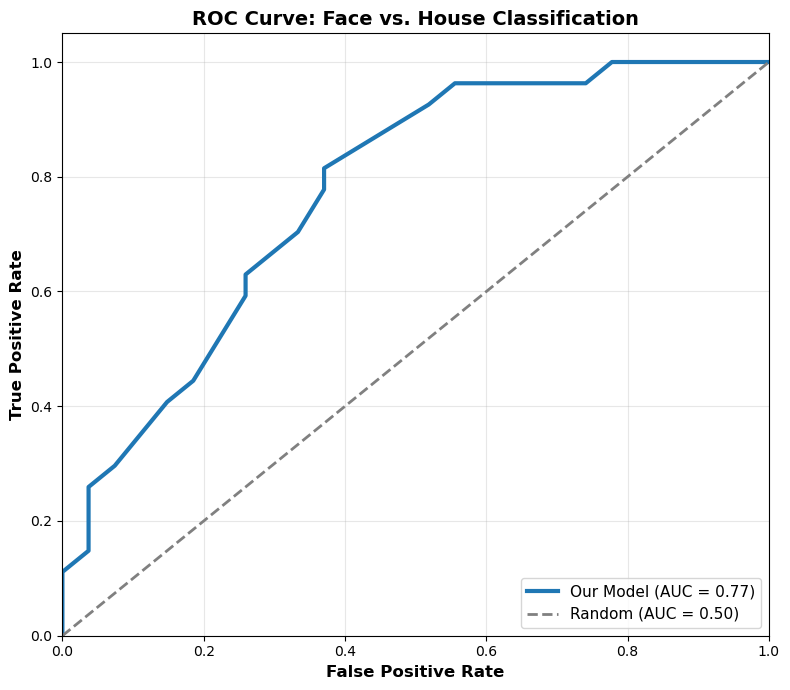


💡 How to read this:
   The closer the blue curve is to the top-left corner, the better!
   The diagonal line represents random guessing.


In [24]:
# Plot ROC curve
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='#1f77b4', lw=3, label=f'Our Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve: Face vs. House Classification', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 How to read this:")
print("   The closer the blue curve is to the top-left corner, the better!")
print("   The diagonal line represents random guessing.")

## Step 13: Leave-One-Run-Out Cross-Validation with Random Forest

Instead of a single train/test split, let's use **Leave-One-Run-Out (LORO)** cross-validation.

### Why Cross-Validation?

**Problems with single split (Step 10):**
- Only tested on 3 specific runs [2, 6, 10]
- What if those runs were particularly easy/hard?
- Don't know if model generalizes to ALL runs

**Leave-One-Run-Out Solution:**
```
Fold  1: Train on 11 runs → Test on run 0
Fold  2: Train on 11 runs → Test on run 1
...
Fold 12: Train on 11 runs → Test on run 11
```

**Benefits:**
- Every run tested exactly once
- Every run helps train 11 different models
- Robust performance estimate (mean ± std across 12 tests)
- No data leakage (test run always separate from training)

In [25]:
from sklearn.model_selection import LeaveOneGroupOut

print("Running Leave-One-Run-Out Cross-Validation...")
print("Training 12 models (one per fold)...\n")

# Initialize cross-validator
logo = LeaveOneGroupOut()

# Store results
cv_scores = []
fold_num = 1

# Cross-validation loop
for train_idx, test_idx in logo.split(flat_fmri, y, groups=run):
    # Split data
    X_train, X_test = flat_fmri[train_idx], flat_fmri[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Train model
    model = RFC(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_train, y_train)
    
    # Evaluate
    score = model.score(X_test, y_test)
    cv_scores.append(score)
    
    # Which run was held out?
    test_run = run[test_idx][0]
    print(f"  Fold {fold_num:2d} (test run {test_run:2d}): {score:.3f} ({score*100:.1f}%)")
    fold_num += 1

# Summary statistics
mean_score = np.mean(cv_scores)
std_score = np.std(cv_scores)

print(f"\n{'='*50}")
print(f"  Mean CV Accuracy: {mean_score:.3f} ± {std_score:.3f}")
print(f"  ({mean_score*100:.1f}% ± {std_score*100:.1f}%)")
print(f"{'='*50}")

print(f"\n✅ Cross-validation complete!")
print(f"\nComparison with single split (Step 10): {test_acc:.3f}")
if abs(mean_score - test_acc) < 0.05:
    print("   → Similar performance (CV confirms single split estimate)")
elif mean_score > test_acc:
    print(f"   → CV shows slightly better generalization (+{(mean_score-test_acc)*100:.1f}%)")
else:
    print(f"   → Single split was lucky (CV is {(test_acc-mean_score)*100:.1f}% lower)")

Running Leave-One-Run-Out Cross-Validation...
Training 12 models (one per fold)...

  Fold  1 (test run  0): 0.500 (50.0%)
  Fold  2 (test run  1): 0.944 (94.4%)
  Fold  3 (test run  2): 0.778 (77.8%)
  Fold  4 (test run  3): 0.222 (22.2%)
  Fold  5 (test run  4): 0.611 (61.1%)
  Fold  6 (test run  5): 0.500 (50.0%)
  Fold  7 (test run  6): 0.667 (66.7%)
  Fold  8 (test run  7): 1.000 (100.0%)
  Fold  9 (test run  8): 0.500 (50.0%)
  Fold 10 (test run  9): 0.500 (50.0%)
  Fold 11 (test run 10): 0.722 (72.2%)
  Fold 12 (test run 11): 0.667 (66.7%)

  Mean CV Accuracy: 0.634 ± 0.205
  (63.4% ± 20.5%)

✅ Cross-validation complete!

Comparison with single split (Step 10): 0.685
   → Single split was lucky (CV is 5.1% lower)


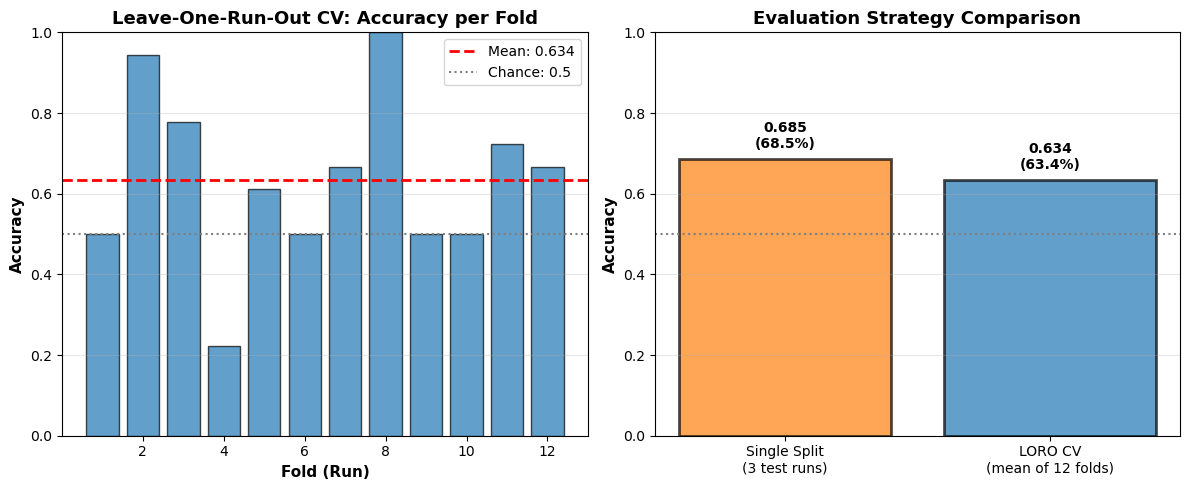


💡 Key Insight:
   LORO CV gives us confidence that the model generalizes
   across ALL scanning sessions, not just 3 test runs.


In [26]:
# Visualize cross-validation results
plt.figure(figsize=(12, 5))

# Plot 1: Scores per fold
plt.subplot(1, 2, 1)
folds = np.arange(1, 13)
plt.bar(folds, cv_scores, color='#1f77b4', alpha=0.7, edgecolor='black')
plt.axhline(y=mean_score, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {mean_score:.3f}')
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, label='Chance: 0.5')
plt.xlabel('Fold (Run)', fontsize=11, fontweight='bold')
plt.ylabel('Accuracy', fontsize=11, fontweight='bold')
plt.title('Leave-One-Run-Out CV: Accuracy per Fold', fontsize=13, fontweight='bold')
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.legend(fontsize=10)

# Plot 2: Comparison with single split
plt.subplot(1, 2, 2)
models = ['Single Split\n(3 test runs)', 'LORO CV\n(mean of 12 folds)']
scores_compare = [test_acc, mean_score]
colors = ['#ff7f0e', '#1f77b4']

bars = plt.bar(models, scores_compare, color=colors, alpha=0.7,
               edgecolor='black', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, label='Chance')
plt.ylabel('Accuracy', fontsize=11, fontweight='bold')
plt.title('Evaluation Strategy Comparison', fontsize=13, fontweight='bold')
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar, score in zip(bars, scores_compare):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{score:.3f}\n({score*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Key Insight:")
print("   LORO CV gives us confidence that the model generalizes")
print("   across ALL scanning sessions, not just 3 test runs.")

## Step 14: Atlas-Based Region Analysis

The atlas is a 3D volume where each voxel has a value indicating which brain region it belongs to.

Instead of treating the brain as a homogeneous blob, we will:
1. **Divide** the brain into anatomical regions using a brain atlas
2. **Train separate models** for each region
3. **Compare** which regions best discriminate faces vs. houses
4. **Visualize** results on a 3D brain surface

**Why is this useful?**
- Identifies specialized brain regions (e.g., fusiform face area)
- Reduces dimensionality (fewer voxels per region)
- Provides anatomical interpretability
- Can guide ROI selection for future studies

**Atlas**: We use the **Glasser parcellation** - divides cortex into 360 regions based on connectivity and function.

In [ ]:
import os, subprocess, shlex
import os
import subprocess

def download_from_drive(file_name,file_ID, base_folder="."):
    DEST_PATH = os.path.join(base_folder, file_name)
    if not os.path.exists(DEST_PATH):
        URL = f"https://drive.usercontent.google.com/download?id={file_ID}&confirm=t"
        cmd = ["wget", "-q", "--show-progress", "--progress=bar:force:noscroll",
            "--no-check-certificate", "-O", DEST_PATH, URL]
        ret = subprocess.call(cmd)  # shell=False by default
        if ret != 0:
            raise RuntimeError("Download failed. Check sharing settings or FILE_ID.")
        else:
            print("Downloaded " + file_name + "!")
    else:
        print(file_name + " already present:", DEST_PATH)

download_from_drive('atlas_labels.csv','1Vf73Yh78xeOiSAcUQSc0kj6k682YzKAB')
download_from_drive('atlas_masks.nii.gz','1rFJS4OxrzDvZjzIFc5Ebv3MEd1AnQAE2')

In [27]:
# Load the Glasser atlas
# Note: This file should be in your working directory
try:
    raw_atlas = nib.load('atlas_masks.nii.gz')
    atlas_data, atlas_affine = raw_atlas.get_fdata(), raw_atlas.affine
    
    print(f"✓ Atlas loaded successfully!")
    print(f"\nAtlas shape: {atlas_data.shape}")
    print(f"Atlas contains {len(np.unique(atlas_data))} unique regions")
    
except FileNotFoundError:
    print("⚠️  Warning: Atlas file not found!")
    print("   This is expected if running outside the original environment.")
    print("   The atlas file 'glasser_MNI152NLin6Asym_labels_p20_resamp_haxbyresamp.nii.gz'")
    print("   would be needed to run this section.")
    atlas_data = None

# Load region labels
try:
    atlas_labels = pd.read_csv('atlas_labels.csv')
    print(f"\n✓ Region labels loaded: {len(atlas_labels)} regions")
    print(f"\nRegion categories (cortex):") 
    cortex_areas = atlas_labels['cortex'].unique()
    print(cortex_areas[:10])  # Show first 10
    if len(cortex_areas) > 10:
        print(f"   ... and {len(cortex_areas) - 10} more")
except FileNotFoundError:
    print("\n⚠️  Warning: Region labels file not found!")
    atlas_labels = None

✓ Atlas loaded successfully!

Atlas shape: (40, 64, 64)
Atlas contains 361 unique regions

✓ Region labels loaded: 360 regions

Region categories (cortex):
['Primary_Visual' 'MT+_Complex_and_Neighboring_Visual_Areas'
 'Dorsal_Stream_Visual' 'Early_Visual' 'Ventral_Stream_Visual'
 'Somatosensory_and_Motor' 'Premotor' 'Posterior_Cingulate'
 'Early_Auditory' 'Temporo-Parieto_Occipital_Junction']
   ... and 13 more


## Step 15: Define Helper Functions

We need two functions:
1. **Extract region data**: Get voxels for a specific cortical area
2. **Train & evaluate**: Train Random Forest on region data

In [30]:
def cortex_to_masked_data(area_name, atlas_data, atlas_labels, fmri_img):
    from nilearn.maskers import NiftiMasker

    # Load generic mask
    generic_mask = nib.load(haxby_dataset.mask)
    
    # Get all region IDs for this cortical area
    area_indexes = atlas_labels[atlas_labels['cortex'] == area_name]['regionID'].values
    
    # Create boolean mask for these regions
    boolean_mask = np.isin(atlas_data, area_indexes)
    
    # Convert to NIfTI mask
    nib_mask = nib.Nifti1Image(
        boolean_mask.astype(float), 
        affine=generic_mask.affine, 
        header=generic_mask.header
    )
    
    # Extract data
    masked_data = NiftiMasker(mask_img=nib_mask).fit_transform(fmri_img)
    
    return masked_data


def cortex_area_ml(region_data, y, train_index, test_index):
    # Split data
    xtrn, xtst = region_data[train_index], region_data[test_index]
    ytrn, ytst = y[train_index], y[test_index]
    
    # Train model
    local_model = RFC(n_estimators=100, max_depth=10, random_state=42).fit(xtrn, ytrn)
    
    # Evaluate
    discrete_pred = local_model.predict(xtst)
    acc = accuracy_score(ytst, discrete_pred)
    
    cont_pred = local_model.predict_proba(xtst)
    ytst_bin = (ytst == local_model.classes_[1]).astype(int)
    roc_auc = roc_auc_score(ytst_bin, cont_pred[:, 1])
    
    return acc, roc_auc

print("✓ Helper functions defined")

✓ Helper functions defined


## Step 16: Train Models for Each Brain Region

This will take a minute - we are training **23 separate models** (one per cortical area)!

In [31]:
if atlas_data is not None and atlas_labels is not None:
    print("Training models for each cortical region...")
    print("This may take 1-2 minutes...\n")
    
    # Store results
    region_results = pd.DataFrame(columns=['acc', 'roc_auc'])
    
    # Loop through unique cortical areas
    for i, area_name in enumerate(atlas_labels['cortex'].unique()):
        try:
            # Extract data for this region
            masked_data = cortex_to_masked_data(
                area_name, atlas_data, atlas_labels, fmri_img
            )
            
            # Train and evaluate
            acc, roc_auc = cortex_area_ml(masked_data, y, train_index, test_index)
            
            # Store results
            region_results.loc[area_name] = [acc, roc_auc]
            
            print(f"  {i+1:2d}/23: {area_name[:40]:40s} | Acc={acc:.3f} | AUC={roc_auc:.3f}")
        except Exception as e:
            print(f"  {i+1:2d}/23: {area_name[:40]:40s} | Error: {str(e)[:30]}")
    
    print(f"\n✓ Training complete! Trained {len(region_results)} region models")
else:
    print("⚠️  Skipping region analysis - atlas files not available")
    region_results = None

Training models for each cortical region...
This may take 1-2 minutes...

   1/23: Primary_Visual                           | Acc=0.611 | AUC=0.721
   2/23: MT+_Complex_and_Neighboring_Visual_Areas | Acc=0.593 | AUC=0.677
   3/23: Dorsal_Stream_Visual                     | Acc=0.722 | AUC=0.840
   4/23: Early_Visual                             | Acc=0.667 | AUC=0.785
   5/23: Ventral_Stream_Visual                    | Acc=0.981 | AUC=0.996
   6/23: Somatosensory_and_Motor                  | Acc=0.574 | AUC=0.596
   7/23: Premotor                                 | Acc=0.630 | AUC=0.707
   8/23: Posterior_Cingulate                      | Acc=0.741 | AUC=0.907
   9/23: Early_Auditory                           | Acc=0.537 | AUC=0.475
  10/23: Temporo-Parieto_Occipital_Junction       | Acc=0.463 | AUC=0.405
  11/23: Dorsolateral_Prefrontal                  | Acc=0.389 | AUC=0.551
  12/23: Temporo-Parieto-Occipital_Junction       | Acc=0.593 | AUC=0.599
  13/23: Superior_Parietal            